In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('melb_data.csv')
print(df.shape)

(13580, 21)


Text(0.5, 1.0, 'Price')

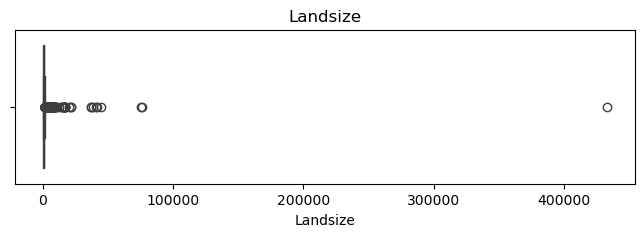

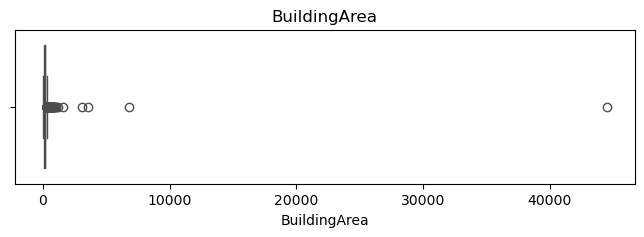

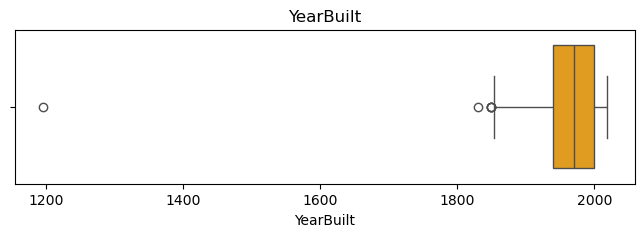

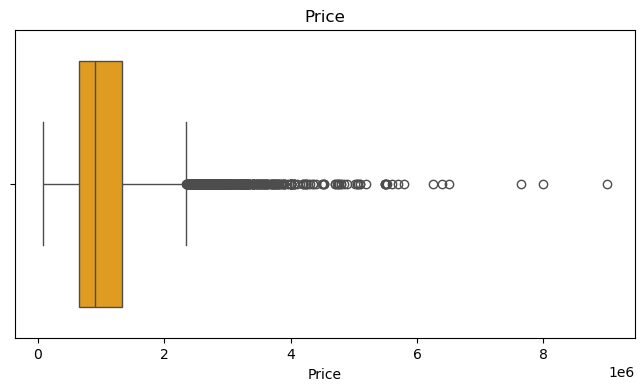

In [38]:
# Visual Check 1: Landsize
plt.figure(figsize = (8, 2))
sns.boxplot(data = df, x = 'Landsize')
plt.title('Landsize')

# Visual Check 2: BuildingArea
plt.figure(figsize = (8, 2))
sns.boxplot(data = df, x = 'BuildingArea', color = 'orange')
plt.title('BuildingArea')

# Visual Check 3: YearBuilt
plt.figure(figsize = (8, 2))
sns.boxplot(data = df, x = 'YearBuilt', color = 'orange')
plt.title('YearBuilt')

# Visual Check 4: Price
plt.figure(figsize = (8, 4))
sns.boxplot(data = df, x = 'Price', color = 'orange')
plt.title('Price')

In [39]:
# missing values per column
missing_counts = df.isnull().sum()

# precentage of missing values
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Table of missing count and percentage
missing_summary = pd.DataFrame(
    {'Missing Count': missing_counts,
    'Percentage (%)': missing_percentages})

# shows the varibles that has missing values in decending order
final_report = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(final_report)

              Missing Count  Percentage (%)
BuildingArea           6450       47.496318
YearBuilt              5375       39.580265
CouncilArea            1369       10.081001
Car                      62        0.456554


In [40]:
df['Car'] = df['Car'].fillna(0)

# remove duplicated rows
df.drop_duplicates()

# Fix the Date data type mismatch so it plots chronologically
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

In [41]:
print("Check")
print("Number of properties with 0 Landsize left:", (df['Landsize'] == 0).sum())
print("Number of properties with 0 Building area left:", (df['BuildingArea'] == 0).sum())
print("Number of missing values left in Car column:", df['Car'].isnull().sum())
print("Total rows remaining in cleaned dataset:", len(df))

Check
Number of properties with 0 Landsize left: 1939
Number of properties with 0 Building area left: 17
Number of missing values left in Car column: 0
Total rows remaining in cleaned dataset: 13580


In [42]:
# creates new features for analysing
df = df.assign(
    Price_per_Landsize = lambda x: df['Price'] / df['Landsize'],
    Distance_Category = pd.cut(
            df['Distance'],
            bins=[0, 10, 20, 30, float('inf')],
            labels=['Near', 'Middle', 'Far', 'Outer']))
df = df.round(4)

Text(0.5, 1.0, 'Correlation Matrix of Housing Variables')

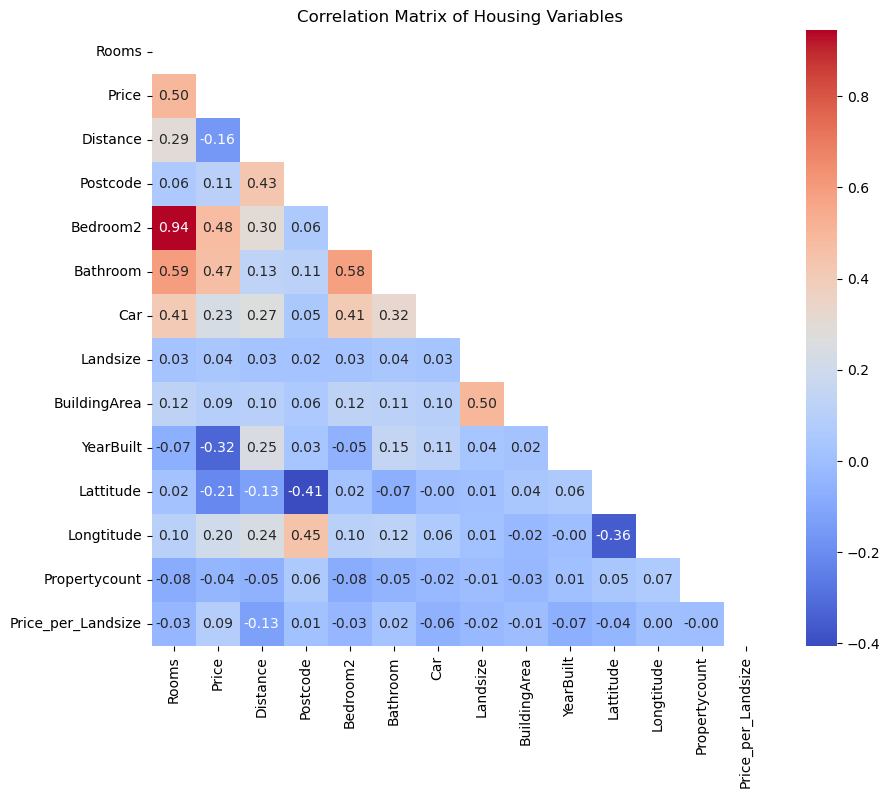

In [43]:
corr = df.corr(numeric_only=True)

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))

# Pass the mask into the heatmap function
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", square=True)

plt.title("Correlation Matrix of Housing Variables")

In [44]:
# remove columns 
df = df.drop(columns=["BuildingArea", "YearBuilt", "CouncilArea"])

Text(0.5, 1.0, 'Correlation Matrix of Housing Variables')

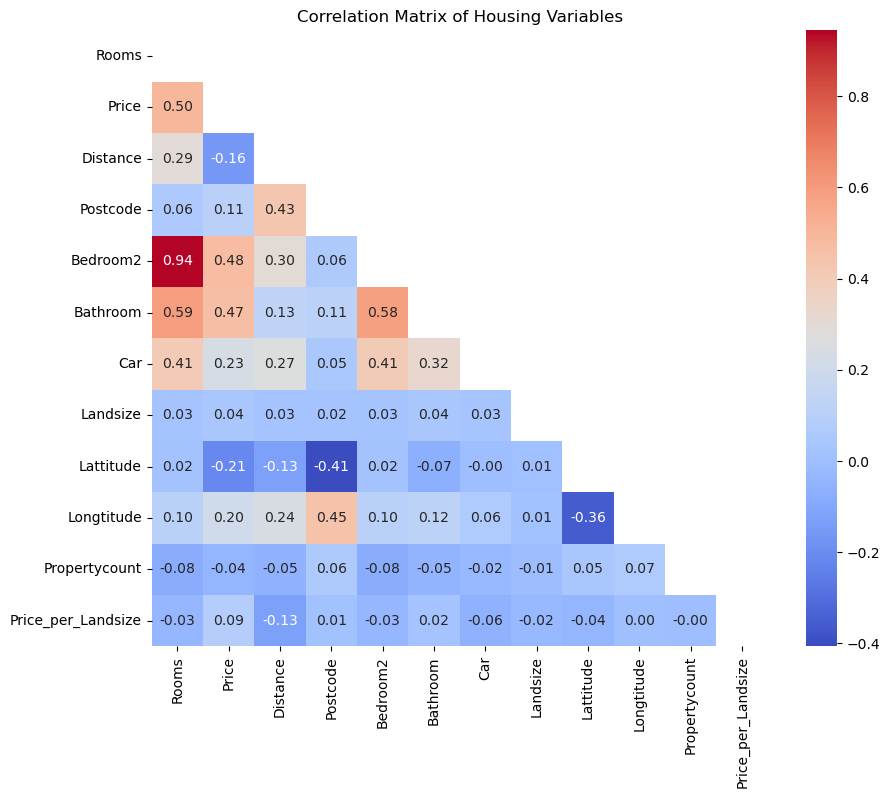

In [45]:
corr = df.corr(numeric_only=True)

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))

# Pass the mask into the heatmap function
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", square=True)

plt.title("Correlation Matrix of Housing Variables")

In [47]:
df.to_csv('cleaned_melb_dataset.csv', index = False)
print('data cleaned successfully!')

data cleaned successfully!
